# Diabetes burden: statistical trends and model benchmarking

This project uses the CDC United States Diabetes Surveillance System indicator dataset, downloaded locally with `Rscript R/download_cdc_datasets.R`, to answer three portfolio questions:

1. How has diabetes burden changed over time across demographic strata?
2. Which strata show the largest recent burden?
3. Can simple statistical and machine-learning models estimate an indicator value from the available stratification fields?

> This is an analytics demonstration, not a clinical risk model. The source is an aggregated surveillance dataset, so predictions describe expected indicator estimates for similar strata and should not be interpreted as individual patient predictions.

## Methods and reproducibility

- **Source:** `data/diabetes_indicators.csv` (download with `Rscript R/download_cdc_datasets.R`)
- **Descriptive statistics:** annual summaries, recent-period change, and stratified rankings
- **Statistical model:** linear trend of the national diagnosed-diabetes percentage
- **Machine-learning models:** one-hot encoded random forest and multilayer perceptron regressor
- **Evaluation:** held-out mean absolute error, root mean squared error, and $R^2$
- **Reproducibility:** fixed random seed and a chronological holdout for the trend model

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')

In [ ]:
DATA_PATH = Path('../data/diabetes_indicators.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/diabetes_indicators.csv')
diabetes = pd.read_csv(DATA_PATH)
diabetes.columns = diabetes.columns.str.strip()
for column in ['Year', 'Estimate', 'Lower Limit', 'Upper Limit']:
    diabetes[column] = pd.to_numeric(diabetes[column], errors='coerce')
diabetes = diabetes.dropna(subset=['Year', 'Estimate']).copy()
diabetes['Year'] = diabetes['Year'].astype(int)
print(f'{len(diabetes):,} usable records; {diabetes.Year.min()}-{diabetes.Year.max()}')
diabetes.head()

11,741 usable records; 2000-2024


,Year,Topic,Indicator,Unit,Estimate,SE Estimate,Lower Limit,Upper Limit,Estimate Footnote,Data Source,Population,Age,Race,Sex,Education,Other Stratification
0,2000,Burden/Magnitude,Diagnosed Diabetes,Percentage,8.3,0.3,7.7,9.0,NaN,National Health Interview Survey (NHIS),All Ages,45-64,All,All,All,NaN
1,2000,Burden/Magnitude,Diagnosed Diabetes,Percentage,15.8,0.8,14.3,17.3,NaN,National Health Interview Survey (NHIS),All Ages,65-74,All,All,All,NaN
2,2000,Burden/Magnitude,Diagnosed Diabetes,Percentage,13.2,0.7,11.8,14.7,NaN,National Health Interview Survey (NHIS),All Ages,75+,All,All,All,NaN
3,2000,Burden/Magnitude,Diagnosed Diabetes,Percentage,1.2,0.1,1.1,1.4,NaN,National Health Interview Survey (NHIS),All Ages,0-44,All,All,All,NaN
4,2000,Burden/Magnitude,Diagnosed Diabetes,Percentage,4.4,0.1,4.2,4.6,NaN,National Health Interview Survey (NHIS),All Ages,Crude,All,All,All,NaN


### Data-quality notes

The extract contains multiple indicators and stratification dimensions. Before comparing values, filter to one indicator and one unit. Suppressed or footnoted values need domain review; this notebook keeps numeric estimates and documents the filtering choices rather than silently combining unlike measures.

,Year,Age,Estimate,Lower Limit,Upper Limit,annual_change,percent_change
517,2015,Age-Adjusted,6.5,6.2,6.8,0.3,4.838710
551,2016,Age-Adjusted,6.4,6.1,6.7,-0.1,-1.538462
585,2017,Age-Adjusted,6.3,6.0,6.6,-0.1,-1.562500
619,2018,Age-Adjusted,6.8,6.5,7.2,0.5,7.936508
653,2019,Age-Adjusted,6.3,6.0,6.5,-0.5,-7.352941
687,2020,Age-Adjusted,6.2,5.9,6.5,-0.1,-1.587302
721,2021,Age-Adjusted,6.4,6.2,6.7,0.2,3.225806
755,2022,Age-Adjusted,6.4,6.1,6.6,0.0,0.000000
789,2023,Age-Adjusted,6.5,6.3,6.8,0.1,1.562500
823,2024,Age-Adjusted,6.6,6.4,6.9,0.1,1.538462


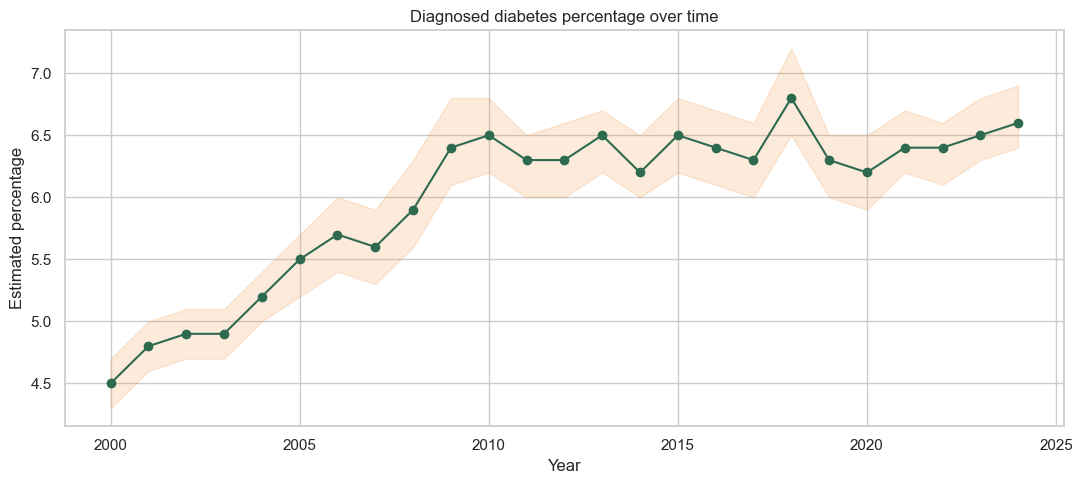

In [6]:
diagnosed = diabetes[
    diabetes['Indicator'].str.contains('Diagnosed Diabetes', case=False, na=False)
    & diabetes['Unit'].eq('Percentage')
].copy()
national = diagnosed[
    diagnosed['Population'].eq('All Ages')
    & diagnosed['Age'].isin(['Age-Adjusted', 'Crude'])
    & diagnosed['Race'].eq('All')
    & diagnosed['Sex'].eq('All')
    & diagnosed['Education'].eq('All')
].copy()

if national.empty:
    raise ValueError('No national diagnosed-diabetes rows were found; inspect the dataset labels before continuing.')

# Prefer age-adjusted estimates for a fair time comparison. If the release
# contains only crude values, retain those instead of failing.
age_preference = {'Age-Adjusted': 0, 'Crude': 1}
national['age_priority'] = national['Age'].map(age_preference).fillna(99)
national = (national.sort_values(['Year', 'age_priority'])
            .drop_duplicates('Year', keep='first')
            .sort_values('Year'))
national['annual_change'] = national['Estimate'].diff()
national['percent_change'] = national['Estimate'].pct_change() * 100

display(national[['Year', 'Age', 'Estimate', 'Lower Limit', 'Upper Limit', 'annual_change', 'percent_change']].tail(10))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national['Year'], national['Estimate'], marker='o', color='#2d6a4f')
ax.fill_between(national['Year'], national['Lower Limit'], national['Upper Limit'], alpha=.18, color='#f28f3b')
ax.set(title='Diagnosed diabetes percentage over time', xlabel='Year', ylabel='Estimated percentage')
plt.tight_layout()
plt.show()

,stratum,Estimate,Lower Limit,Upper Limit
828,75+ | Hispanic | All | All,35.8,29.4,42.6
840,75+ | Non-Hispanic Black | All | All,30.8,25.5,36.6
846,75+ | Non-Hispanic Asian | All | All,29.0,21.7,37.4
827,65-74 | Hispanic | All | All,28.8,23.9,34.3
839,65-74 | Non-Hispanic Black | All | All,28.3,23.7,33.4
845,65-74 | Non-Hispanic Asian | All | All,27.4,20.8,35.2
818,75+ | All | All | All,21.6,20.2,23.2
817,65-74 | All | All | All,19.9,18.5,21.3
834,75+ | Non-Hispanic White | All | All,18.5,17.1,20.1
826,45-64 | Hispanic | All | All,17.1,14.9,19.6


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


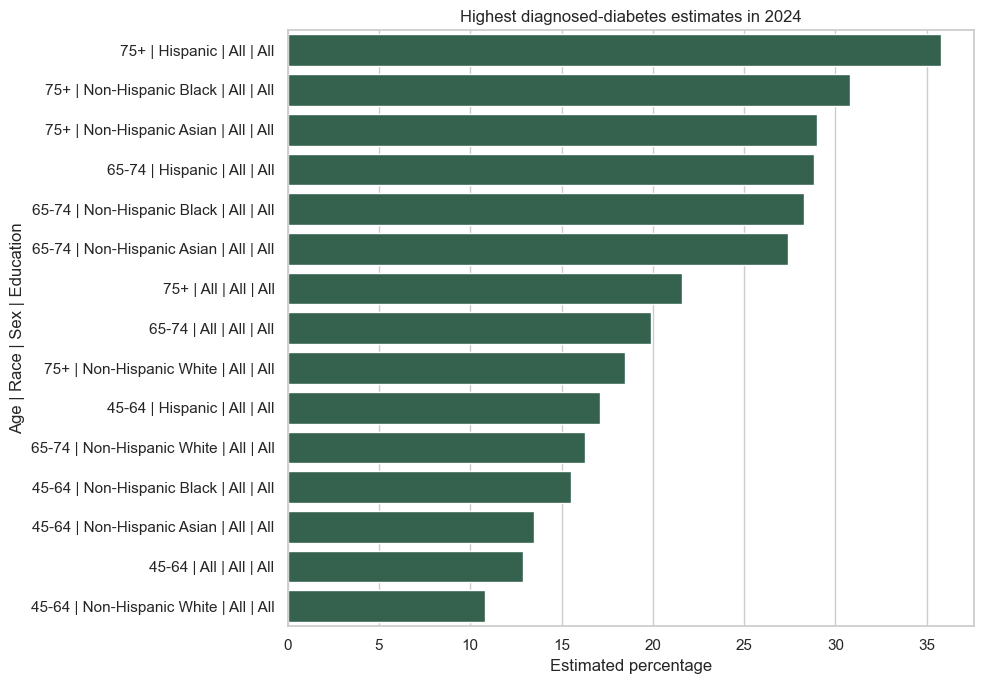

In [9]:
latest_year = diagnosed['Year'].max()
latest = diagnosed[
    diagnosed['Year'].eq(latest_year)
    & diagnosed['Population'].eq('All Ages')
].copy()
latest['stratum'] = latest[['Age', 'Race', 'Sex', 'Education']].astype(str).agg(' | '.join, axis=1)
top_strata = (latest.sort_values('Estimate', ascending=False)
              .drop_duplicates(subset=['stratum', 'Estimate'])
              .head(15))
display(top_strata[['stratum', 'Estimate', 'Lower Limit', 'Upper Limit']])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_strata, y='stratum', x='Estimate', color='#2d6a4f')
plt.title(f'Highest diagnosed-diabetes estimates in {latest_year}')
plt.xlabel('Estimated percentage')
plt.ylabel('Age | Race | Sex | Education')
plt.tight_layout()
plt.show()

In [10]:
# We estimate aggregated percentages from categorical strata and year.
# A chronological split prevents future observations from leaking into training.
model_data = diagnosed.dropna(subset=['Estimate']).copy()
model_features = ['Year', 'Population', 'Age', 'Race', 'Sex', 'Education', 'Other Stratification']
model_features = [
    column for column in model_features
    if column in model_data.columns and model_data[column].notna().any()
]
cutoff = model_data['Year'].quantile(.8)
train = model_data[model_data['Year'] <= cutoff]
test = model_data[model_data['Year'] > cutoff]
X_train, y_train = train[model_features], train['Estimate']
X_test, y_test = test[model_features], test['Estimate']

categorical = X_train.select_dtypes(exclude='number').columns.tolist()
numeric = X_train.select_dtypes(include='number').columns.tolist()
preprocess = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical),
])
models = {
    'Random forest': RandomForestRegressor(n_estimators=250, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    'Neural network': MLPRegressor(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=300, random_state=RANDOM_STATE),
}

scores = []
for name, estimator in models.items():
    pipeline = Pipeline([('preprocess', preprocess), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    scores.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, prediction),
        'RMSE': mean_squared_error(y_test, prediction) ** 0.5,
        'R2': r2_score(y_test, prediction),
    })

pd.DataFrame(scores).sort_values('MAE').round(3)

,model,MAE,RMSE,R2
0,Random forest,1.055,1.725,0.982
1,Neural network,1.339,2.145,0.973


## Portfolio interpretation

The strongest portfolio story is not simply which model wins. It is whether the model is appropriate for the data-generating process, whether the holdout reflects how the model would be used, and whether uncertainty is communicated. For a production version, add cross-validation by year, bootstrap confidence intervals, model calibration, and a data dictionary review with a public-health subject-matter expert.